In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snss
from sklearn.model_selection import train_test_split

Load Dataset

In [3]:
df = pd.read_csv('churn_combined.csv')
df.head(n=10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


Data Cleaning

In [4]:
# Delete Fitur
df = df.drop(columns=['State', 'Area code'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account length          3333 non-null   int64  
 1   International plan      3333 non-null   str    
 2   Voice mail plan         3333 non-null   str    
 3   Number vmail messages   3333 non-null   int64  
 4   Total day minutes       3333 non-null   float64
 5   Total day calls         3333 non-null   int64  
 6   Total day charge        3333 non-null   float64
 7   Total eve minutes       3333 non-null   float64
 8   Total eve calls         3333 non-null   int64  
 9   Total eve charge        3333 non-null   float64
 10  Total night minutes     3333 non-null   float64
 11  Total night calls       3333 non-null   int64  
 12  Total night charge      3333 non-null   float64
 13  Total intl minutes      3333 non-null   float64
 14  Total intl calls        3333 non-null   int64  
 15

In [5]:
df.isnull().sum()

Account length            0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Handling Duplicated

In [6]:
df.duplicated().sum()

np.int64(0)

Distribusi Fitur

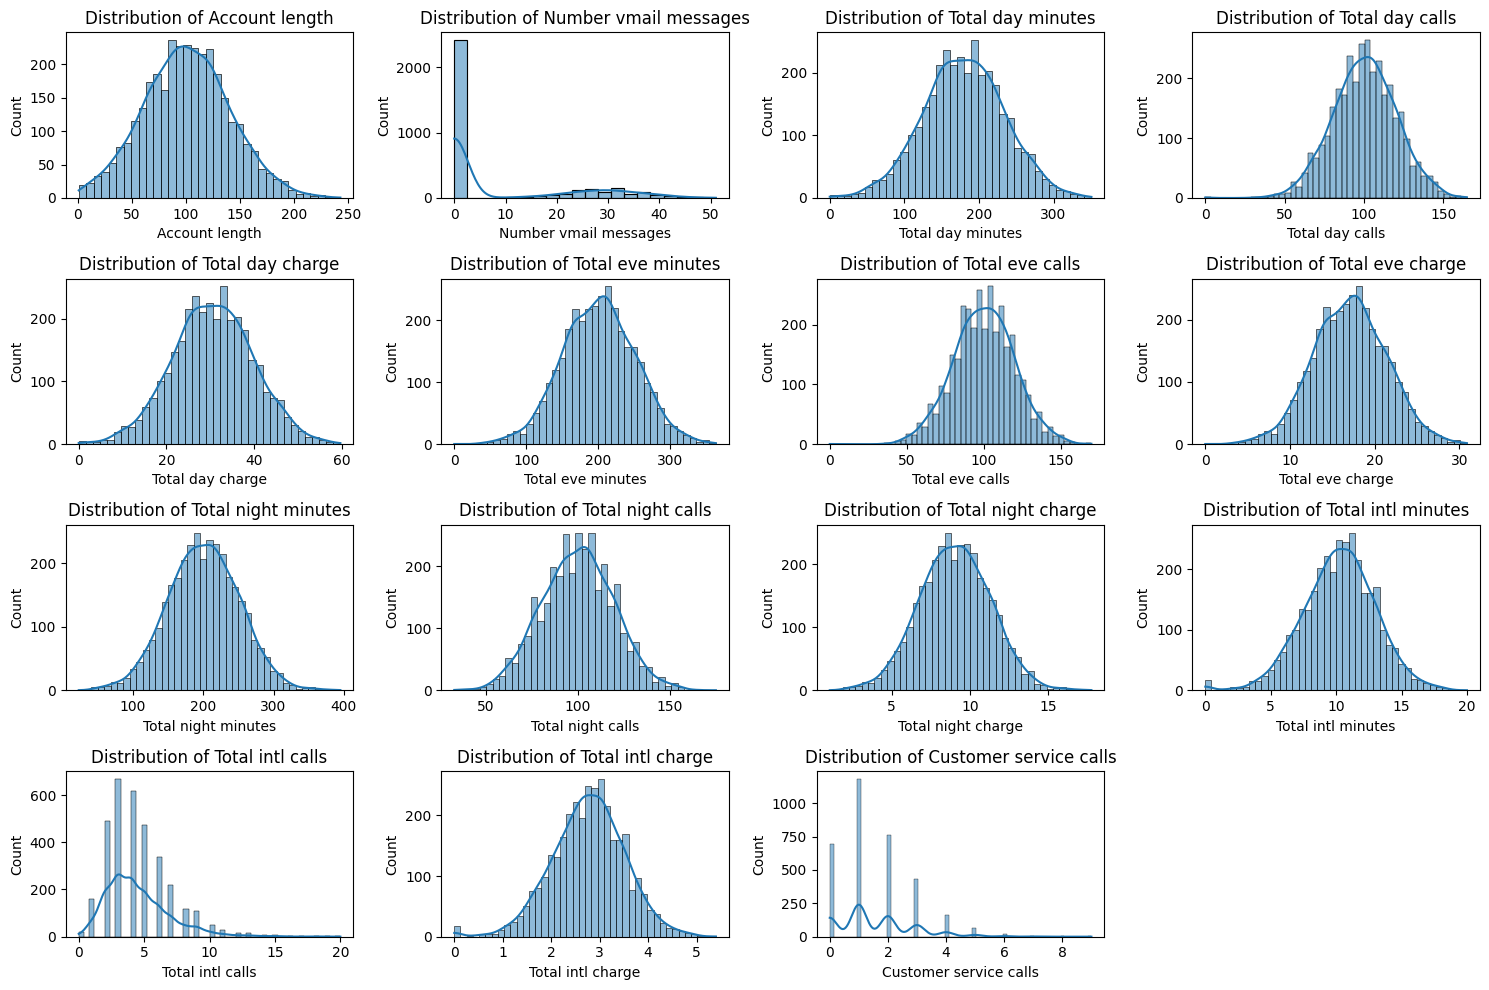

In [7]:
num_features = df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Outlier Detection

In [9]:
num_features = df.select_dtypes(include=['number']).columns

outlier_summary = []

for col in num_features:
    if col == 'Churn':
            continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        'Fitur': col,
        'Jumlah Outlier': len(outliers),
        'Persentase': f'{(len(outliers) / len(df) * 100):.2f}%',
        'Batas Bawah': lower_bound,
        'Batas Atas': upper_bound
    })

df_outlier = pd.DataFrame(outlier_summary)
print(df_outlier)

                     Fitur  Jumlah Outlier Persentase  Batas Bawah  Batas Atas
0           Account length              18      0.54%       -5.500     206.500
1    Number vmail messages               1      0.03%      -30.000      50.000
2        Total day minutes              25      0.75%       34.650     325.450
3          Total day calls              23      0.69%       46.500     154.500
4         Total day charge              25      0.75%        5.890      55.330
5        Total eve minutes              24      0.72%       63.550     338.350
6          Total eve calls              20      0.60%       46.500     154.500
7         Total eve charge              24      0.72%        5.400      28.760
8      Total night minutes              30      0.90%       64.550     337.750
9        Total night calls              22      0.66%       48.000     152.000
10      Total night charge              30      0.90%        2.915      15.195
11      Total intl minutes              46      1.38

Outlier Removal

In [10]:
initial_rows = df.shape[0]

for col in num_features:
    if col == 'Churn':
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

final_rows = df.shape[0]
rows_dropped = initial_rows - final_rows

print('Pembersihan selesai!')
print(f'Jumlah baris awal: {initial_rows}')
print(f'Jumlah baris setelah dibersihkan: {final_rows}')
print(f'Total baris yang dihapus: {rows_dropped} ({rows_dropped/initial_rows*100:.2f}%)')

Pembersihan selesai!
Jumlah baris awal: 3333
Jumlah baris setelah dibersihkan: 2797
Total baris yang dihapus: 536 (16.08%)


Save Dataset

In [11]:
df.to_csv('dataset.csv', index=False)
print('Dataset saved to dataset.csv')

Dataset saved to dataset.csv
